# Lab 6
### Morphology

Skimage morphology operators' documentation:
https://scikit-image.org/docs/dev/api/skimage.morphology.html

In [28]:
from commonfunctions import *
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.morphology import binary_erosion, binary_dilation, binary_closing,skeletonize, thin
from skimage.measure import find_contours
from skimage.draw import rectangle

# Show the figures / plots inside the notebook
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


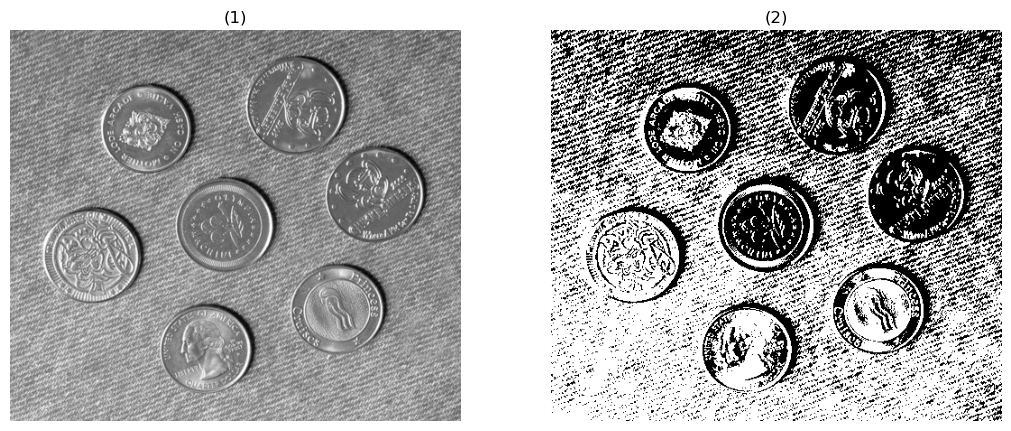

In [29]:
'''
1) Erosion / Dilation:
    - Load "coins.jpg" from the img folder
    - Convert the image to binary
    - Write 2 functions each applying 1 of the erosion/dilation algorithms (with adjustable square window size) manually to the binary image
    - Use Skimage's "binary_erosion" & "binary_dilation" & show the results
'''

coinsImg = io.imread('./img/coins.jpg')
coinsImg = rgb2gray(coinsImg)

def binaryConversion(img, low_threshold=0.7, high_threshold=1):
    binaryImg = np.copy(img)
    mask = (img >= low_threshold) & (img <= high_threshold)
    binaryImg[mask] = 1
    binaryImg[~mask] = 0
    return binaryImg

binaryCoinsImg = binaryConversion(coinsImg, 0.55)
show_images([coinsImg, binaryCoinsImg])


In [30]:
def erosion(img):
    height, width = img.shape
    outputImg = np.copy(img)
    mask = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]])

    for i in range(height):
        for j in range(width):
            match = True
            for m in range(i - 1, i + 2):
                if(m < 0 or m >= height):
                    continue
                for n in range(j - 1, j + 2):
                    if(n < 0 or n >= width):
                      continue
                    if(mask[m - i + 1][n - j + 1] == 1 and img[m][n] == 0):
                        match = False
            if(match):
                outputImg[i][j] = 1
            else:
                outputImg[i][j] = 0

    return outputImg



In [31]:
def dilation(img):
    height, width = img.shape
    outputImg = np.copy(img)
    mask = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]])

    for i in range(height):
        for j in range(width):
            hit = False
            for m in range(i - 1, i + 2):
                if(m < 0 or m >= height):
                    continue
                for n in range(j - 1, j + 2):
                    if(n < 0 or n >= width):
                      continue
                    if(mask[m - i + 1][n - j + 1] == 1 and img[m][n] == 1):
                        hit = True
            if(hit):
                outputImg[i][j] = 1
            else:
                outputImg[i][j] = 0

    return outputImg

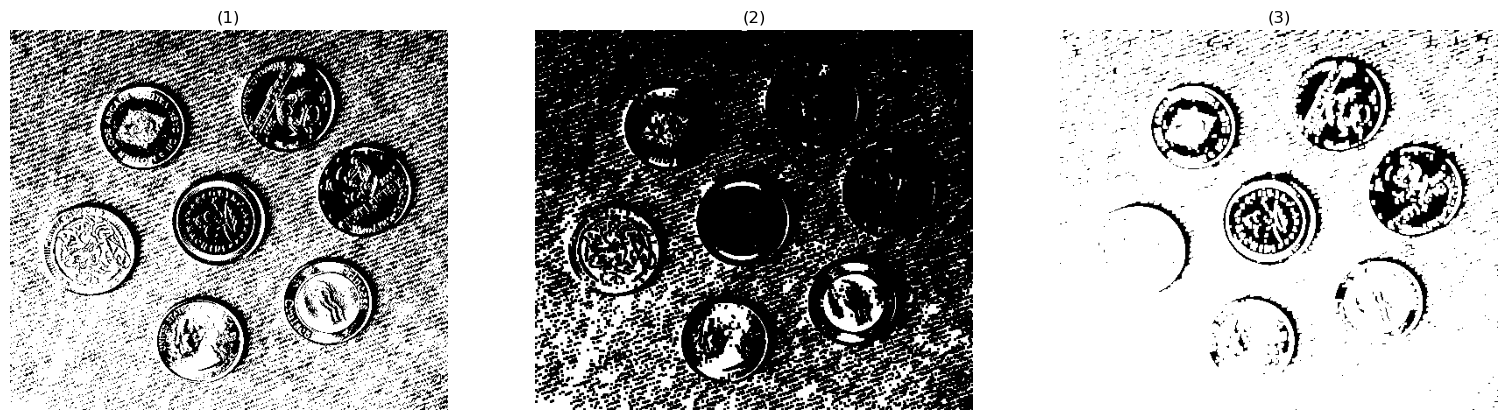

In [32]:
erosionCoinsImg = erosion(binaryCoinsImg)
dilationCoinsImg = dilation(binaryCoinsImg)

show_images([binaryCoinsImg, erosionCoinsImg, dilationCoinsImg])

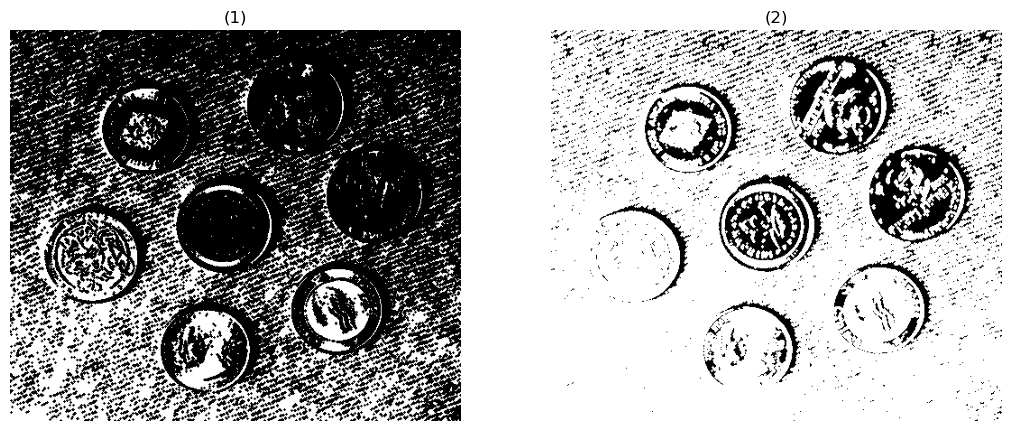

In [33]:
erosionCoinsImg_ski = binary_erosion(binaryCoinsImg) 
dilationCoinsImg_ski = binary_dilation(binaryCoinsImg) 

show_images([erosionCoinsImg_ski, dilationCoinsImg_ski])

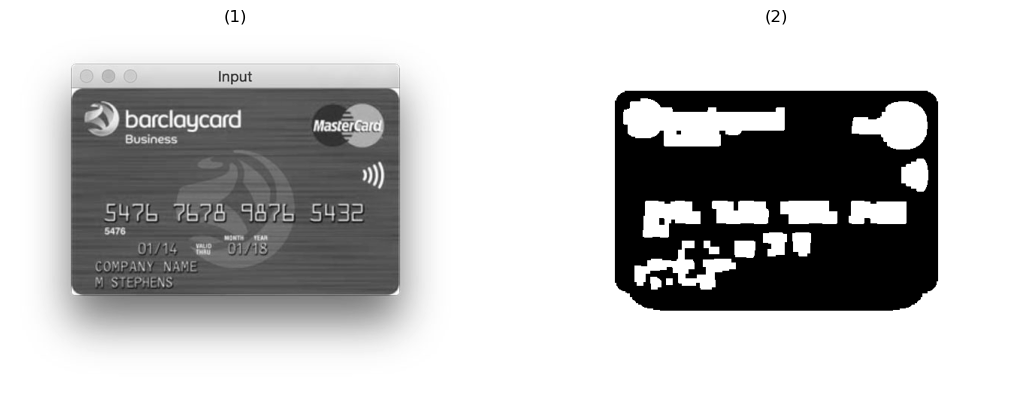

In [34]:
'''
2) Case Study: Credit Card Number Extraction
    - Load "card.jpg" from the img folder
    - Convert the image to binary by brightness thresholding maintaining the card number details for extraction
    - Use your erosion/dilation functions, or Skimage's functions only if you didn't implement them, to apply closing
        Note: The goal of this step is to join the card number into 4 sets of connected pixels
    - Use Skimage's "find_contours" to get the bounding boxes for the credit card's numbers by filtering on aspect ratio (between 2.5 & 3.5)
        Note: When using "find_contours(img, 0.8)" the o/p is a list of contours each having:
                - contour[:,0] being the Y values of the contour perimeter points
                - contour[:,1] being the X values of the contour perimeter points
'''

cardImg = io.imread('./img/card.jpg')
cardImg = rgb2gray(cardImg)

binaryCardImg = binaryConversion(cardImg, 0.68)

binaryCardImg = dilation(binaryCardImg)
binaryCardImg = dilation(binaryCardImg)
binaryCardImg = dilation(binaryCardImg)
binaryCardImg = dilation(binaryCardImg)
binaryCardImg = dilation(binaryCardImg)
binaryCardImg = dilation(binaryCardImg)
binaryCardImg = erosion(binaryCardImg)
binaryCardImg = erosion(binaryCardImg)

show_images([cardImg, binaryCardImg])



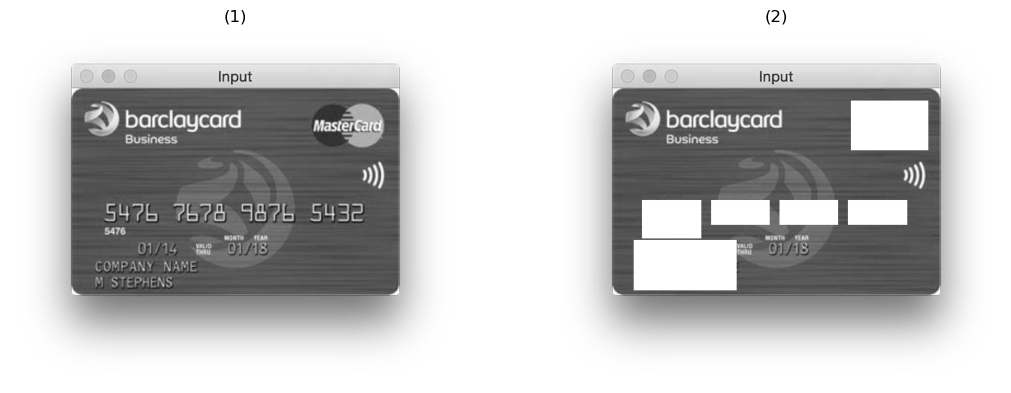

In [35]:
contours = find_contours(binaryCardImg, 0.8)

bounding_boxes = []
for contour in contours:
    YMin = int(math.floor(np.min(contour[:,0])))
    YMax = int(math.ceil(np.max(contour[:,0])))
    XMin = int(math.floor(np.min(contour[:,1])))
    XMax = int(math.ceil(np.max(contour[:,1])))
    width_t = XMax - XMin
    height_t = YMax - YMin

    if(height_t == 0):
        continue
    
    ratio = float(width_t) / float(height_t)

    if(ratio >= 1.5 and ratio <= 2.5):
        tempArr  = np.array([XMin, XMax, YMin, YMax]).astype(np.uint16)
        bounding_boxes.append(tempArr)
    
bounding_boxes = np.array(bounding_boxes)    

#When provided with the correct format of the list of bounding_boxes, this section will set all pixels inside boxes in img_with_boxes
resultCardImg = np.copy(cardImg)
for box in bounding_boxes:
    [Xmin, Xmax, Ymin, Ymax] = box
    rr, cc = rectangle(start = (Ymin,Xmin), end = (Ymax,Xmax), shape=cardImg.shape)
    resultCardImg[rr, cc] = 1 #set color white

show_images([cardImg, resultCardImg])

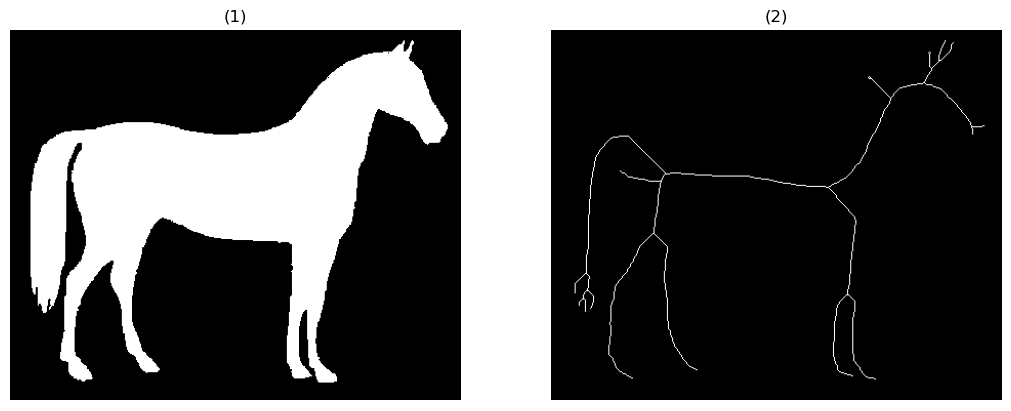

In [36]:
'''
3) Skeletonization:
    - Load "horse.jpg" from the img folder 
    - Use a binary threshold of 0.9 to remove invisible noise in the background
    - Use Skimage's "skeletonize(image)" to acquire the image's skeleton & show it
    - Use Skimage's "thin(image, max_iter)" with values of max_iter 5/10/15/20 & show it
'''

horseImg = io.imread('./img/horse.jpg')
horseImg = rgb2gray(horseImg)
horseImg = binaryConversion(horseImg, 0.9)

skeletonizedHorseImg = skeletonize(horseImg)

show_images([horseImg, skeletonizedHorseImg])

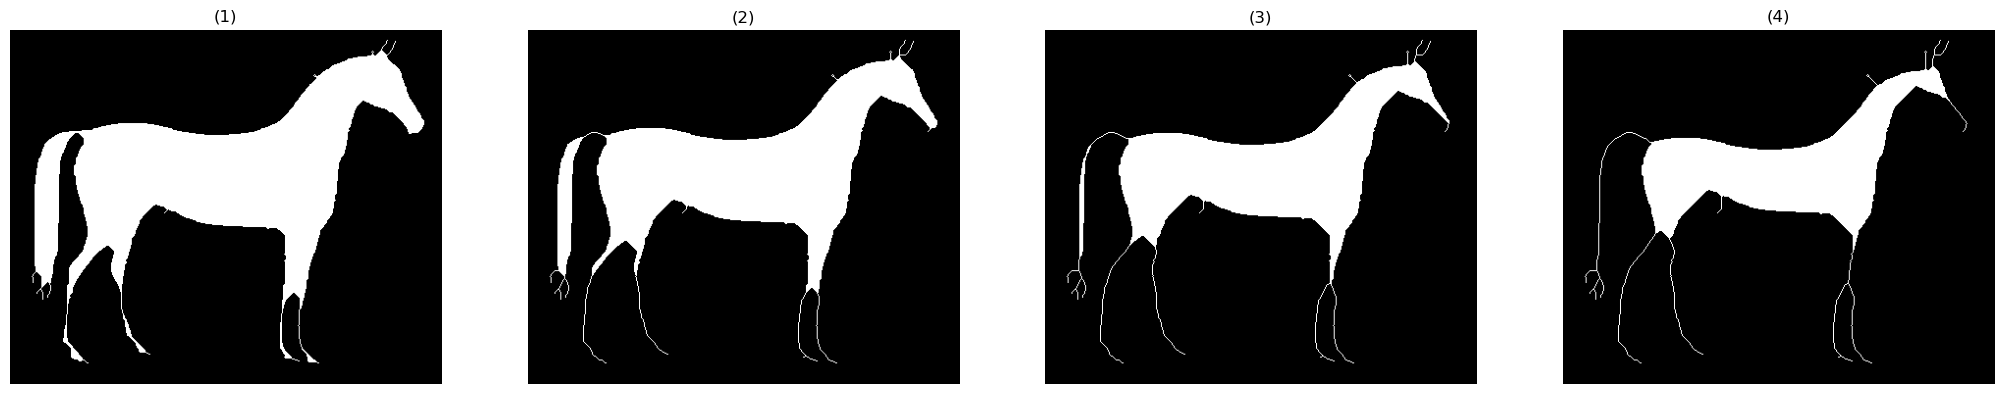

In [37]:
horseImgThin5 = thin(horseImg, 5)
horseImgThin10 = thin(horseImg, 10)
horseImgThin15 = thin(horseImg, 15)
horseImgThin20 = thin(horseImg, 20)

show_images([horseImgThin5, horseImgThin10, horseImgThin15, horseImgThin20])